# ZORA : CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

27/11/24 Santiago

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [41]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun
import nana.topo.zora      as zora

In [8]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style

## Load Data

In [9]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [11]:
ifilename = datapath + mcfilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_4bar_MC_DEP_deco.h5


In [12]:
datadeco   = evtfun.get_deconvoluted_data(data)
#evtfun.test_get_deconvoluted_data(data)

In [14]:
datadeco

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,enecc,enecn
0,0,0,37,51,52,0.000402,0,0.009006,0,0.0,0.0
1,0,0,38,43,52,0.000832,0,0.017880,0,0.0,0.0
2,0,0,38,44,52,0.000463,0,0.013932,0,0.0,0.0
3,0,0,38,47,52,0.000436,0,0.009499,0,0.0,0.0
4,0,0,38,47,53,0.000938,0,0.011403,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5280416,15037,1,30,30,60,0.000395,0,0.081036,0,0.0,0.0
5280417,15037,1,30,31,60,0.000821,0,0.045941,0,0.0,0.0
5280418,15037,1,30,33,61,0.000355,0,0.019439,0,0.0,0.0
5280419,15037,1,30,34,61,0.000409,0,0.022328,0,0.0,0.0


## Event loop

In [58]:
groupid = 'dataset_id'
evtdata = data.groupby(groupid)

In [146]:
ievt = 0
evt = evtdata.get_group(ievt)

In [147]:
evt.head()

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,enecc,enecn
0,0,0,37,51,52,0.000402,0,0.009006,0,0.0,0.0
1,0,0,38,43,52,0.000832,0,0.017880,0,0.0,0.0
2,0,0,38,44,52,0.000463,0,0.013932,0,0.0,0.0
3,0,0,38,47,52,0.000436,0,0.009499,0,0.0,0.0
4,0,0,38,47,53,0.000938,0,0.011403,0,0.0,0.0


In [148]:
zevt = zora.zora_event(evt, bin_info, bin_widths)

,ext_ene,ext_degree,ext_dist,blob_id,blob_ene,blob_nodes,blob_edges,dataset_id,nhits,energy,spine_nhits,spine_energy,ngraphs,lgraph_nodes,lgraph_edges,lgraph_energy
0,0.014800,12,23,0,0.321126,23,132,0,383,1.0,105,0.48896,1,105,567,1.0
1,0.002773,6,23,1,0.072798,14,56,0,383,1.0,105,0.48896,1,105,567,1.0


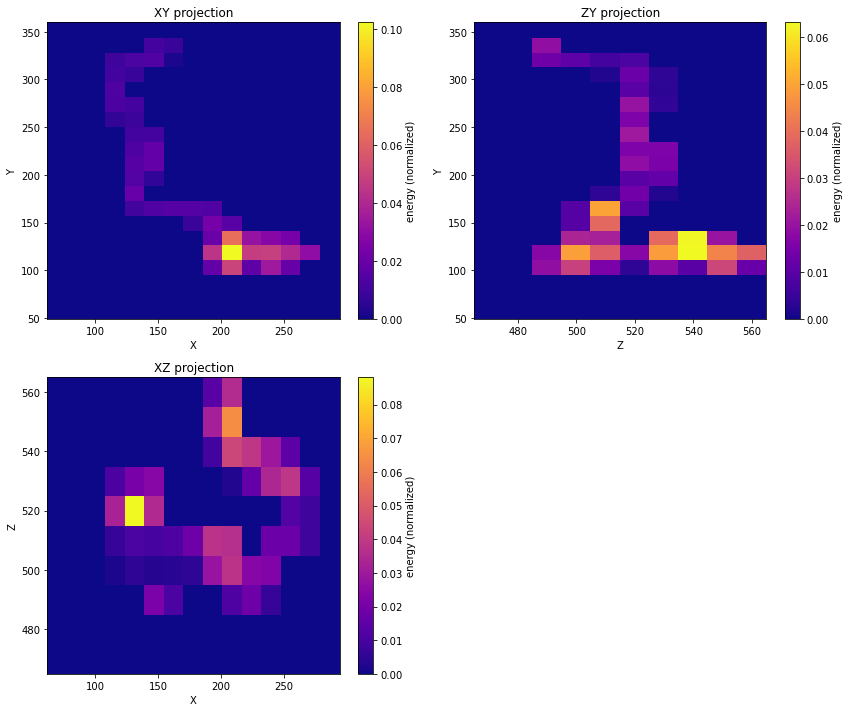

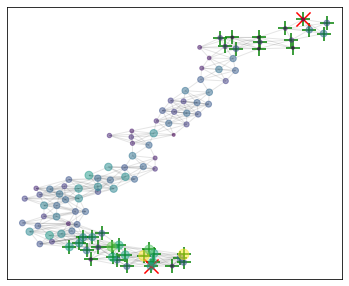

In [149]:
coors = evtfun.get_coors(evt, bin_info)
ene   = evt.enecn.values
bins  = evtfun.get_bins(coors, bin_widths)
evtfun.event_display(coors, bins = bins, ene = ene);

pltext.canvas(1, 1)
longest_graph = zevt['longest_graph']
extremes      = zevt['extremes']
blobs        = zevt['blobs']
graphfun.display_graph(longest_graph, extremes, blobs)

zevt['summary'].head()

In [150]:
dfout = zora.zora(nevents = 10)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5
Number of events in input file 10778
Number of events to process 10
Event 0
saving zora_output.h5
Number of events in output file 9


In [145]:
dfout

,ext_ene,ext_degree,ext_dist,blob_id,blob_ene,blob_nodes,blob_edges,dataset_id,nhits,energy,spine_nhits,spine_energy,ngraphs,lgraph_nodes,lgraph_edges,lgraph_energy
0,0.003542,13,28,0,0.219792,33,218,1,688,1.0,175,0.513415,1,175,1150,1.000000
1,0.000762,5,28,1,0.010233,7,20,1,688,1.0,175,0.513415,1,175,1150,1.000000
2,0.009298,5,24,0,0.267835,17,57,2,656,1.0,73,0.241817,3,71,270,0.980593
3,0.067039,5,24,1,0.262299,9,28,2,656,1.0,73,0.241817,3,71,270,0.980593
4,0.000831,9,15,0,0.138686,58,440,3,526,1.0,355,0.878824,1,355,3324,1.000000
5,0.000852,10,15,1,0.095121,52,389,3,526,1.0,355,0.878824,1,355,3324,1.000000
6,0.000265,9,16,0,0.156721,73,605,4,638,1.0,463,0.885814,1,463,4534,1.000000
7,0.000316,10,16,1,0.088129,35,245,4,638,1.0,463,0.885814,1,463,4534,1.000000
8,0.013245,10,24,0,0.178239,14,61,5,649,1.0,115,0.358274,2,77,345,0.542863
9,0.004760,6,24,1,0.083220,15,71,5,649,1.0,115,0.358274,2,77,345,0.542863
